In [1]:
import tensorflow as tf
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import os
import pandas as pd
import json
import re
import random


In [2]:
imgdir_path = pathlib.Path('Img_prueba')
csv_path = "caption_data_prueba.csv"
json_path = "char_dict.json"

file_list = sorted([str(path) for path in imgdir_path.glob('*.bmp')])

print("Número de imágenes:", len(file_list))
print(file_list[:5])

Número de imágenes: 12167
['Img_prueba\\101_Fabricio.bmp', 'Img_prueba\\101_Frank.bmp', 'Img_prueba\\101_Nina.bmp', 'Img_prueba\\101_alfonso.bmp', 'Img_prueba\\101_carlos.bmp']


Image Size: (97, 412, 1)
Image Size: (125, 577, 1)
Image Size: (113, 411, 1)
Image Size: (109, 409, 1)
Image Size: (93, 440, 1)
Image Size: (114, 384, 1)


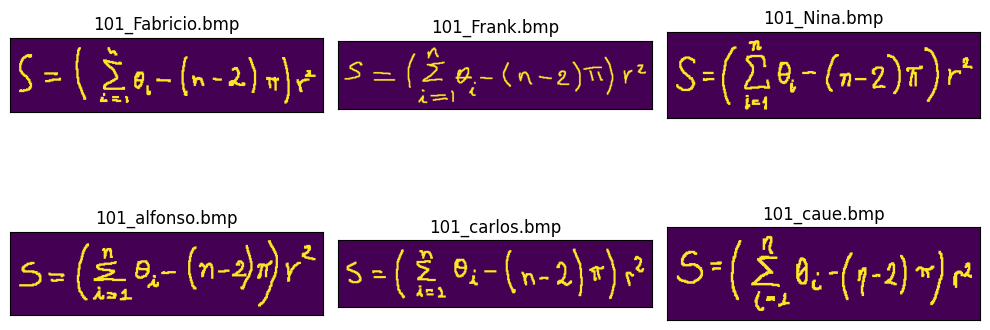

In [3]:
fig = plt.figure(figsize=(10,5))

for i, file in enumerate(file_list[:6]):
    img_raw = tf.io.read_file(file)
    img = tf.image.decode_image(img_raw)

    print('Image Size:', img.shape)

    ax = fig.add_subplot(2, 3, i+1)
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(img)
    ax.set_title(os.path.basename(file), size=12)

plt.tight_layout()
plt.show()

In [4]:
df = pd.read_csv(csv_path)

df.rename(columns={
    'Column1': 'image_name',
    'Column2': 'caption'
}, inplace=True)

df.head()

,image_name,caption
0,18_em_0,x _ { k } x x _ { k } + y _ { k } y x _ { k }
1,18_em_10,2 6
2,18_em_11,q _ { t } = 2 q
3,18_em_12,\frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } }
4,18_em_13,4 ^ { 2 } + 4 ^ { 2 } + \frac { 4 } { 4 }


In [5]:
df["path"] = df["image_name"].apply(
    lambda x: str(imgdir_path / (x + ".bmp"))
)

df.head()

,image_name,caption,path
0,18_em_0,x _ { k } x x _ { k } + y _ { k } y x _ { k },Img_prueba\18_em_0.bmp
1,18_em_10,2 6,Img_prueba\18_em_10.bmp
2,18_em_11,q _ { t } = 2 q,Img_prueba\18_em_11.bmp
3,18_em_12,\frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } },Img_prueba\18_em_12.bmp
4,18_em_13,4 ^ { 2 } + 4 ^ { 2 } + \frac { 4 } { 4 },Img_prueba\18_em_13.bmp


In [6]:
file_list = df["path"].tolist()
labels = df["caption"].tolist()

In [7]:
with open(json_path, "r", encoding="utf8") as f:
    rules = json.load(f)

# extraer comandos LaTeX
latex_commands = set()

for expr in df["caption"]:
    cmds = re.findall(r'\\[a-zA-Z]+', str(expr))
    latex_commands.update(cmds)

# comparar
json_commands = set(rules.keys())

faltantes = latex_commands - json_commands

print("Comandos en dataset:", len(latex_commands))
print("Comandos en JSON:", len(json_commands))
print("Faltantes:", faltantes)

Comandos en dataset: 35
Comandos en JSON: 76
Faltantes: {'\\leq', '\\geq', '\\cdot', '\\rightarrow', '\\int', '\\sum', '\\exists', '\\forall', '\\mu', '\\beta', '\\cdots', '\\cos', '\\lim', '\\gamma', '\\ldots', '\\sqrt', '\\alpha', '\\frac', '\\times', '\\neq', '\\pi', '\\sin', '\\lambda', '\\log', '\\theta', '\\tan', '\\Delta', '\\infty', '\\div', '\\sigma', '\\phi', '\\prime', '\\limits', '\\pm', '\\in'}


In [8]:
all_tokens = ["<PAD>", "<BOS>", "<EOS>", "<UNK>"] + sorted(json_commands | faltantes)

token2id = {token: i for i, token in enumerate(all_tokens)}
id2token = {i: token for token, i in token2id.items()}

with open("vocabulario.json", "w", encoding="utf-8") as f:
    json.dump(token2id, f, ensure_ascii=False, indent=4)

In [9]:
with open("vocabulario.json", "r") as f:
    vocab = json.load(f)

In [10]:
def tokenize_latex(expr):
    return expr.split()

def encode_latex(expr, vocab):
    tokens = tokenize_latex(expr)

    encoded = [vocab["<BOS>"]]

    for t in tokens:
        encoded.append(vocab.get(t, vocab["<UNK>"]))

    encoded.append(vocab["<EOS>"])

    return encoded

labels_encoded = [encode_latex(eq, vocab) for eq in labels]

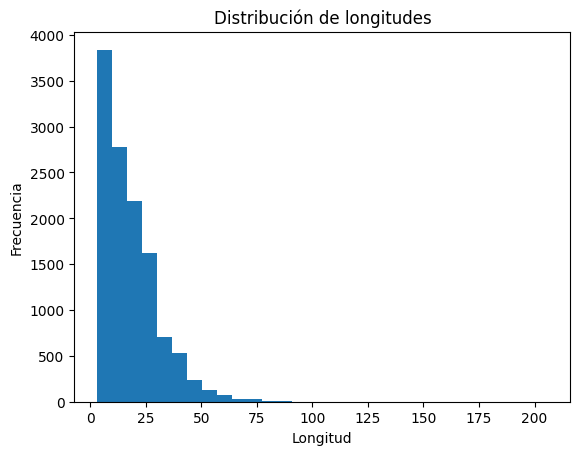

Min: 3
Max: 206
Promedio: 17.872441850908196
P95: 41.0


In [11]:
lengths = [len(seq) for seq in labels_encoded]

plt.hist(lengths, bins=30)
plt.title("Distribución de longitudes")
plt.xlabel("Longitud")
plt.ylabel("Frecuencia")
plt.show()

print("Min:", np.min(lengths))
print("Max:", np.max(lengths))
print("Promedio:", np.mean(lengths))
print("P95:", np.percentile(lengths, 95))

In [12]:
for i in range(15):
    print("Original:", labels[i])
    print("Tokens:", tokenize_latex(labels[i]))
    print("Encoded:", labels_encoded[i])
    print("-"*40)

Original: x _ { k } x x _ { k } + y _ { k } y x _ { k }
Tokens: ['x', '_', '{', 'k', '}', 'x', 'x', '_', '{', 'k', '}', '+', 'y', '_', '{', 'k', '}', 'y', 'x', '_', '{', 'k', '}']
Encoded: [1, 109, 85, 112, 96, 114, 109, 109, 85, 112, 96, 114, 9, 110, 85, 112, 96, 114, 110, 109, 85, 112, 96, 114, 2]
----------------------------------------
Original: 2 6
Tokens: ['2', '6']
Encoded: [1, 16, 20, 2]
----------------------------------------
Original: q _ { t } = 2 q
Tokens: ['q', '_', '{', 't', '}', '=', '2', 'q']
Encoded: [1, 102, 85, 112, 105, 114, 25, 16, 102, 2]
----------------------------------------
Original: \frac { p e ^ { t } } { 1 - ( 1 - p ) e ^ { t } }
Tokens: ['\\frac', '{', 'p', 'e', '^', '{', 't', '}', '}', '{', '1', '-', '(', '1', '-', 'p', ')', 'e', '^', '{', 't', '}', '}']
Encoded: [1, 57, 112, 101, 90, 84, 112, 105, 114, 114, 112, 15, 11, 7, 15, 11, 101, 8, 90, 84, 112, 105, 114, 114, 2]
----------------------------------------
Original: 4 ^ { 2 } + 4 ^ { 2 } + \frac { 4

In [13]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 50  # puedes ajustar con P95

labels_padded = pad_sequences(
    labels_encoded,
    maxlen=max_len,
    padding="post",
    value=vocab["<PAD>"]
)

for i in range(5):
    print("Padded:", labels_padded[i])

Padded: [  1 109  85 112  96 114 109 109  85 112  96 114   9 110  85 112  96 114
 110 109  85 112  96 114   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [ 1 16 20  2  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0]
Padded: [  1 102  85 112 105 114  25  16 102   2   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [  1  57 112 101  90  84 112 105 114 114 112  15  11   7  15  11 101   8
  90  84 112 105 114 114   2   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
Padded: [  1  18  84 112  16 114   9  18  84 112  16 114   9  57 112  18 114 112
  18 114   2   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0

In [14]:
img_width = 384
img_height = 128

def load_and_preprocess(path, label):
    image = tf.io.read_file(path)
    # Leer como RGB
    image = tf.image.decode_bmp(image, channels=3)
    # Convertir a escala de grises
    image = tf.image.rgb_to_grayscale(image)
    image = tf.image.resize(image, [img_height, img_width])
    image = image / 255.0
    image = tf.cast(image, tf.float32)

    label = tf.cast(label, tf.int32)
    if len(image.shape) == 2:
        image = tf.expand_dims(image, axis=-1)

    return image, label

In [15]:
ds = tf.data.Dataset.from_tensor_slices((file_list, labels_padded))
ds = ds.map(load_and_preprocess)

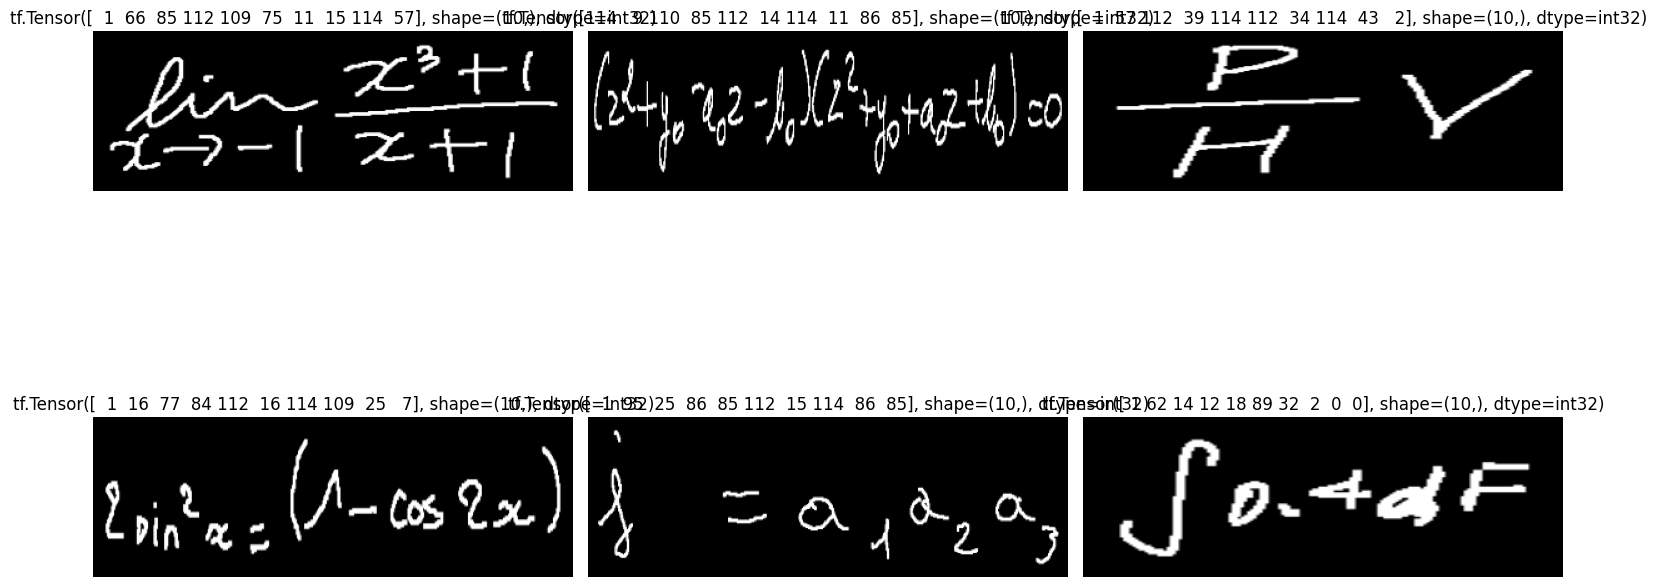

In [16]:
# Tomar 6 índices aleatorios
indices = random.sample(range(len(file_list)), 6)

fig = plt.figure(figsize=(15,10))

for i, idx in enumerate(indices):
    img, label = load_and_preprocess(file_list[idx], labels_padded[idx])
    
    img_np = img.numpy()
    
    if img_np.shape[-1] == 1:
        img_np = img_np[:, :, 0]

    ax = fig.add_subplot(2, 3, i+1)
    ax.imshow(img_np, cmap="gray")
    ax.set_title(str(label[:10]))  # primeros tokens
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Mezclar dataset
BUFFER_SIZE = len(file_list)
ds = ds.shuffle(buffer_size=BUFFER_SIZE, reshuffle_each_iteration=False)

# Tomar 5000 muestras
ds_small = ds.take(12160)

# Tamaños
total_size = 12160
train_size = int(0.7 * total_size)
val_size = int(0.10 * total_size)
test_size = total_size - train_size - val_size

# División
ds_train = ds_small.take(train_size)
ds_temp = ds_small.skip(train_size)

ds_val = ds_temp.take(val_size)
ds_test = ds_temp.skip(val_size)

# Batching
BATCH_SIZE = 32

ds_train = ds_train.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [ ]:
# -----------------------------
# Residual Block
# -----------------------------
def bloque_res(x, filters):
    shortcut = x

    if x.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(
            filters, (1,1), padding='same'
        )(shortcut)

    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('gelu')(x) # <-- GELU aplicado aquí

    x = tf.keras.layers.Conv2D(filters, (3,3), padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.Add()([x, shortcut])
    x = tf.keras.layers.Activation('gelu')(x) # <-- GELU aplicado aquí

    return x


# -----------------------------
# Entrada
# -----------------------------
inputs = tf.keras.Input(shape=(128, 384, 1))


# -----------------------------
# CNN
# -----------------------------

x = tf.keras.layers.Conv2D(32, (3,3), padding='same', activation='gelu')(inputs)

x = bloque_res(x, 32)
x = tf.keras.layers.MaxPool2D((2,2))(x)

x = bloque_res(x, 64)
x = tf.keras.layers.MaxPool2D((2,2))(x)

x = bloque_res(x, 128)
x = tf.keras.layers.MaxPool2D((2,1))(x)

x = bloque_res(x, 256)
x = tf.keras.layers.MaxPool2D((2,1))(x)

# -----------------------------
# CNN → LSTM
# -----------------------------

x = tf.keras.layers.Resizing(height=8, width=max_len)(x) # Salida: (8, 50, 256)

x = tf.keras.layers.Permute((2, 1, 3))(x)

x = tf.keras.layers.Reshape((max_len, 8 * 256))(x)

x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.3)
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(256, return_sequences=True, dropout=0.3)
)(x)

vocab_size = len(vocab)

outputs = tf.keras.layers.Dense(
    vocab_size,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=3e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 2. Añadido el ReduceLROnPlateau
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,     
    patience=2, 
    min_lr=1e-6,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "mejor_modelo.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 384,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 384,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 384,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 384,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 384,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 384,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 384,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 384,  │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 192,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 192,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 192,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 192,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 192,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 192,   │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 192,   │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 192,   │          0 │ batch_normalizat

 Total params: 7,582,771 (28.93 MB)

 Trainable params: 7,580,851 (28.92 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [19]:
EPOCHS = 20

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6564 - loss: 1.7329
Epoch 1: val_loss improved from None to 3.07867, saving model to mejor_modelo.h5



Epoch 1: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 2198s 8s/step - accuracy: 0.6807 - loss: 1.4715 - val_accuracy: 0.6663 - val_loss: 3.0787
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6981 - loss: 1.2819
Epoch 2: val_loss improved from 3.07867 to 1.89171, saving model to mejor_modelo.h5



Epoch 2: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 2355s 9s/step - accuracy: 0.6996 - loss: 1.2745 - val_accuracy: 0.6839 - val_loss: 1.8917
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7078 - loss: 1.2167
Epoch 3: val_loss improved from 1.89171 to 1.19657, saving model to mejor_modelo.h5



Epoch 3: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 2573s 10s/step - accuracy: 0.7085 - loss: 1.2126 - val_accuracy: 0.7117 - val_loss: 1.1966
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7145 - loss: 1.1681
Epoch 4: val_loss improved from 1.19657 to 1.14389, saving model to mejor_modelo.h5



Epoch 4: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1713s 6s/step - accuracy: 0.7150 - loss: 1.1645 - val_accuracy: 0.7199 - val_loss: 1.1439
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7203 - loss: 1.1295
Epoch 5: val_loss improved from 1.14389 to 1.12847, saving model to mejor_modelo.h5


...


Epoch 14: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1667s 6s/step - accuracy: 0.7540 - loss: 0.8784 - val_accuracy: 0.7482 - val_loss: 0.9333
Epoch 15/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7567 - loss: 0.8608
Epoch 15: val_loss did not improve from 0.93328
266/266 ━━━━━━━━━━━━━━━━━━━━ 1670s 6s/step - accuracy: 0.7574 - loss: 0.8564 - val_accuracy: 0.7479 - val_loss: 0.9833
Epoch 16/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7605 - loss: 0.8381
Epoch 16: val_loss improved from 0.93328 to 0.92555, saving model to mejor_modelo.h5



Epoch 16: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1671s 6s/step - accuracy: 0.7608 - loss: 0.8360 - val_accuracy: 0.7523 - val_loss: 0.9256
Epoch 17/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7645 - loss: 0.8170
Epoch 17: val_loss improved from 0.92555 to 0.90677, saving model to mejor_modelo.h5



Epoch 17: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1675s 6s/step - accuracy: 0.7644 - loss: 0.8163 - val_accuracy: 0.7538 - val_loss: 0.9068
Epoch 18/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7673 - loss: 0.7993
Epoch 18: val_loss improved from 0.90677 to 0.89700, saving model to mejor_modelo.h5



Epoch 18: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1681s 6s/step - accuracy: 0.7673 - loss: 0.8002 - val_accuracy: 0.7522 - val_loss: 0.8970
Epoch 19/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7706 - loss: 0.7849
Epoch 19: val_loss improved from 0.89700 to 0.88230, saving model to mejor_modelo.h5



Epoch 19: finished saving model to mejor_modelo.h5
266/266 ━━━━━━━━━━━━━━━━━━━━ 1684s 6s/step - accuracy: 0.7701 - loss: 0.7861 - val_accuracy: 0.7557 - val_loss: 0.8823
Epoch 20/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7727 - loss: 0.7730
Epoch 20: val_loss did not improve from 0.88230
266/266 ━━━━━━━━━━━━━━━━━━━━ 1693s 6s/step - accuracy: 0.7720 - loss: 0.7753 - val_accuracy: 0.7578 - val_loss: 0.8930


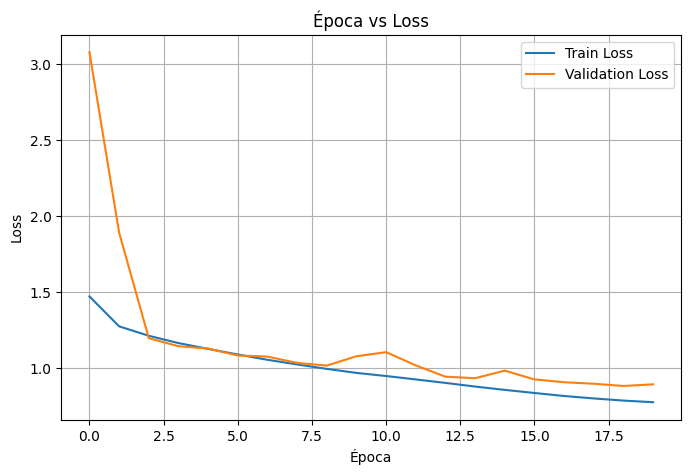

In [20]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Época')
plt.ylabel('Loss')
plt.title('Época vs Loss')
plt.legend()
plt.grid()

plt.show()

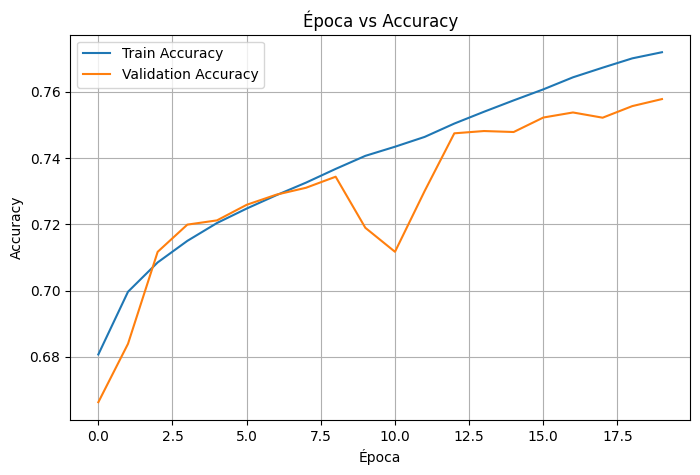

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.title('Época vs Accuracy')
plt.legend()
plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Imagen 1
Real : A _ { j } = \sqrt { j ( j + 1 ) }
Pred : \sqrt _ { n } = \sqrt { { { { { } } } } } }
--------------------------------------------------
Imagen 2
Real : X , X _ { t }
Pred : x _ { n } } _ _ { }
--------------------------------------------------
Imagen 3
Real : \alpha = ( \alpha _ { 1 } , \alpha _ { 2 } , \ldots , \alpha _ { n } )
Pred : ( = x _ _ _ } } _ _ _ _ _ _ _ _ _ _ } } } }
--------------------------------------------------
Imagen 4
Real : x ^ { \prime } = x \cos \theta + y \sin \theta
Pred : x ^ { \prime } = \sin \sin \sin \theta \theta \theta \theta
--------------------------------------------------
Imagen 5
Real : + \ldots + \alpha _ { i - 1 } y _ { i - 1 } + \alpha _ { i + 1 } y _ { i + 1 } + \ldots + \alpha _ { n + 1 } y _ { n + 1 }
Pred : x _ { 1 } + 1 _ { } + _ _ { } _ _ _ } } } _ { { } } } } } } } } _ _ _ _ _ _ _ _ _ _ _ _ { } }
--------------------------------------------------
Imagen 6
Real : \frac { 1 } { \sqrt { r } }

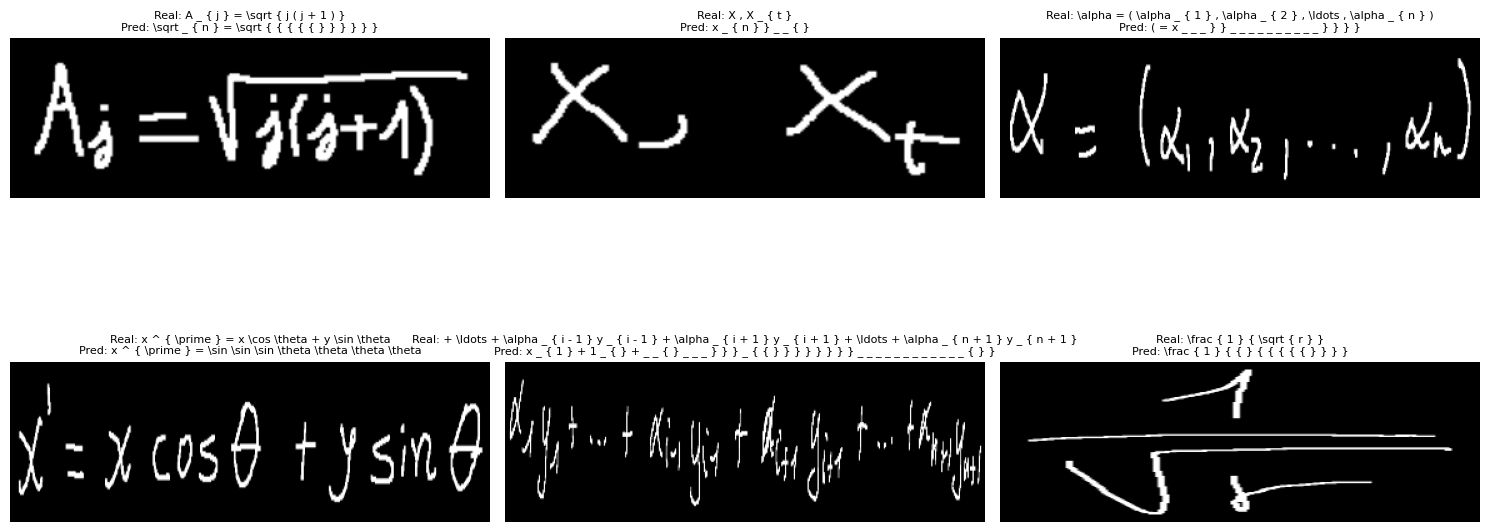

In [22]:
# Función para decodificar tokens a texto
def decode_sequence(seq, id2token):
    tokens = []
    for i in seq:
        token = id2token.get(int(i), "<UNK>")
        
        if token == "<EOS>":
            break
            
        if token not in ["<PAD>", "<BOS>"]:
            tokens.append(token)
            
    return " ".join(tokens)


plt.figure(figsize=(15,8))

# Tomar un batch del dataset de test
for images, labels in ds_test.take(1):
    
    # Predicciones del modelo
    predictions = model.predict(images)
    
    # Convertir probabilidades a tokens
    predicted_tokens = np.argmax(predictions, axis=-1)
    
    # Mostrar 6 imágenes
    for i in range(6):
        
        img = images[i].numpy().squeeze()
        
        real = decode_sequence(labels[i].numpy(), id2token)
        pred = decode_sequence(predicted_tokens[i], id2token)
        
        # Mostrar imagen
        plt.subplot(2,3,i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Real: {real}\nPred: {pred}", fontsize=8)
        plt.axis("off")
        
        # Imprimir también en consola
        print("Imagen", i+1)
        print("Real :", real)
        print("Pred :", pred)
        print("-"*50)

plt.tight_layout()
plt.show()

In [23]:
#08/04

test_loss, test_accuracy = model.evaluate(ds_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

76/76 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7584 - loss: 0.8883
Test Loss: 0.8882641792297363
Test Accuracy: 0.7583882212638855


In [24]:
for images, labels in ds_test.take(1):

    predictions = model.predict(images)
    predicted_tokens = np.argmax(predictions, axis=-1)

    for i in range(5):
        print("Real :", labels[i][:15].numpy())
        print("Pred :", predicted_tokens[i][:15])
        print("-"*40)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Real : [  1  27  85 112  95 114  25  78 112  95   7  95   9  15   8]
Pred : [  1  78  85 112  99 114  25  78 112 112 112 112 112 114 114]
----------------------------------------
Real : [  1  44  10  44  85 112 105 114   2   0   0   0   0   0   0]
Pred : [  1 109  85 112  99 114 114  85  85 112 114   0   0   0   0]
----------------------------------------
Real : [  1  49  25   7  49  85 112  15 114  10  49  85 112  16 114]
Pred : [  1   7  25 109  85  85  85 114 114  85  85  85  85  85  85]
----------------------------------------
Real : [  1 109  84 112  74 114  25 109  53  81   9 110  77  81   2]
Pred : [  1 109  84 112  74 114  25  77  77  77  81  81  81  81   0]
----------------------------------------
Real : [  9  64   9  49  85 112  94  11  15 114 110  85 112  94  11]
Pred : [  1 109  85 112  15 114   9  15  85 112 114   9  85  85 112]
----------------------------------------


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


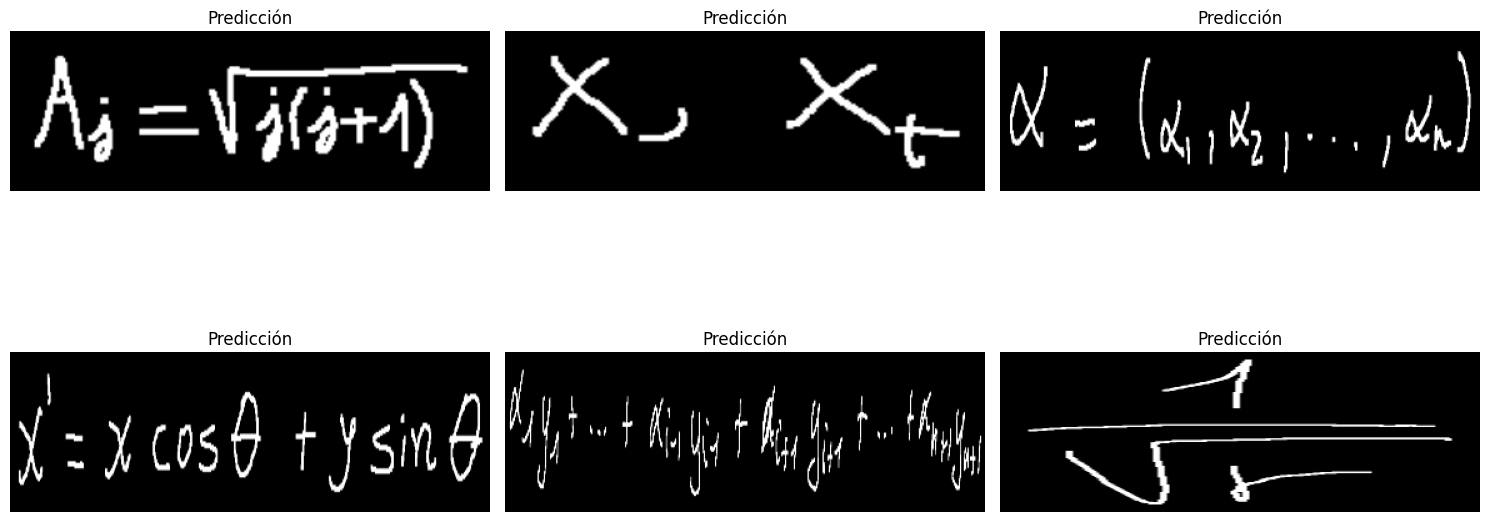

In [25]:
plt.figure(figsize=(15,8))

for images, labels in ds_test.take(1):

    predictions = model.predict(images)
    predicted_tokens = np.argmax(predictions, axis=-1)

    for i in range(6):

        img = images[i].numpy().squeeze()

        plt.subplot(2,3,i+1)
        plt.imshow(img, cmap="gray")
        plt.title("Predicción")
        plt.axis("off")

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Imagen 1
Real : A _ { j } = \sqrt { j ( j + 1 ) }
Pred : \sqrt _ { n } = \sqrt { { { { { } } } } } }
--------------------------------------------------
Imagen 2
Real : X , X _ { t }
Pred : x _ { n } } _ _ { }
--------------------------------------------------
Imagen 3
Real : \alpha = ( \alpha _ { 1 } , \alpha _ { 2 } , \ldots , \alpha _ { n } )
Pred : ( = x _ _ _ } } _ _ _ _ _ _ _ _ _ _ } } } }
--------------------------------------------------
Imagen 4
Real : x ^ { \prime } = x \cos \theta + y \sin \theta
Pred : x ^ { \prime } = \sin \sin \sin \theta \theta \theta \theta
--------------------------------------------------
Imagen 5
Real : + \ldots + \alpha _ { i - 1 } y _ { i - 1 } + \alpha _ { i + 1 } y _ { i + 1 } + \ldots + \alpha _ { n + 1 } y _ { n + 1 }
Pred : x _ { 1 } + 1 _ { } + _ _ { } _ _ _ } } } _ { { } } } } } } } } _ _ _ _ _ _ _ _ _ _ _ _ { } }
--------------------------------------------------
Imagen 6
Real : \frac { 1 } { \sqrt { r } }

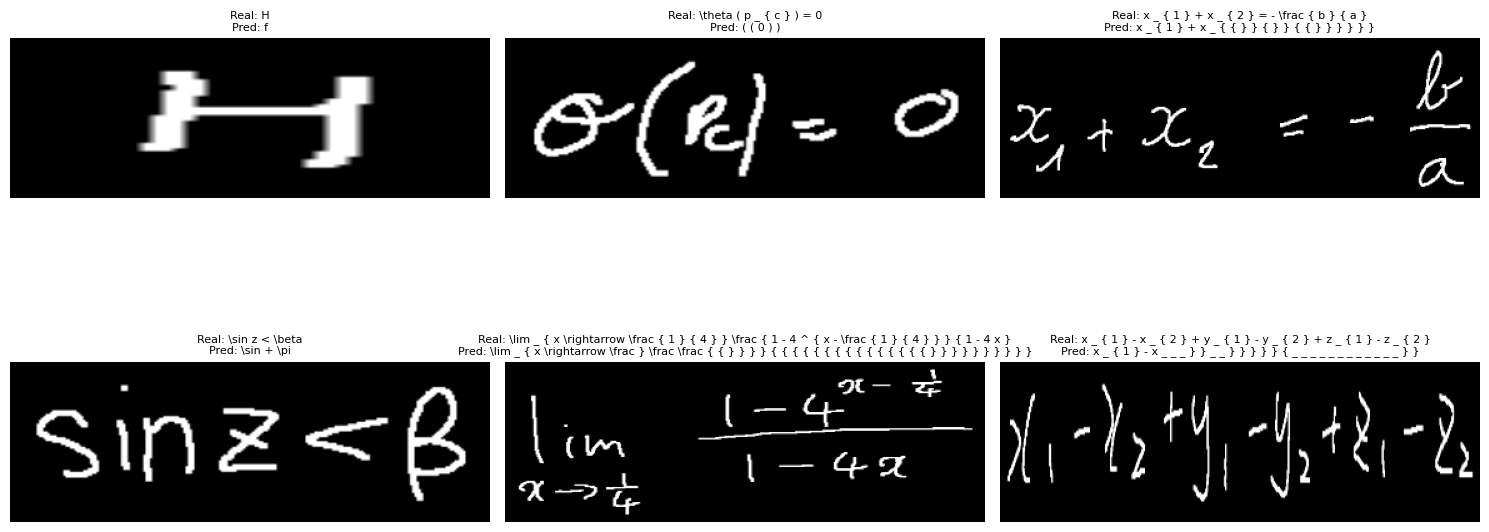

In [27]:
def decode_sequence(seq, id2token):
    tokens = []
    for i in seq:
        token = id2token.get(int(i), "<UNK>")
        
        if token == "<EOS>":
            break
            
        if token not in ["<PAD>", "<BOS>"]:
            tokens.append(token)
            
    return " ".join(tokens)


plt.figure(figsize=(15,8))

# Tomar un batch del dataset de test
for images, labels in ds_test.take(2):
    
    # Predicciones del modelo
    predictions = model.predict(images)
    
    # Convertir probabilidades a tokens
    predicted_tokens = np.argmax(predictions, axis=-1)
    
    # Mostrar 6 imágenes
    for i in range(6):
        
        img = images[i].numpy().squeeze()
        
        real = decode_sequence(labels[i].numpy(), id2token)
        pred = decode_sequence(predicted_tokens[i], id2token)
        
        # Mostrar imagen
        plt.subplot(2,3,i+1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Real: {real}\nPred: {pred}", fontsize=8)
        plt.axis("off")
        
        # Imprimir también en consola
        print("Imagen", i+1)
        print("Real :", real)
        print("Pred :", pred)
        print("-"*50)

plt.tight_layout()
plt.show()